# Silicon–Organic Hybrid Slot Electro-Optic Modulator: RF–Optical Co-Simulation and Vπ·L Extraction

In this example, we simulate a silicon–organic hybrid (SOH) electro-optic modulator that overcomes the intrinsic limitations of silicon for efficient electro-optic modulation by using an organic material with a strong Pockels effect inside a slot waveguide. The device concept follows `Heiner Zwickel et al., “Silicon-organic hybrid (SOH) modulators for intensity-modulation/direct-detection links with line rates of up to 120 Gbit/s,” Optics Express 25, 23784 (2017).` DOI: [10.1364/OE.25.023784](https://doi.org/10.1364/OE.25.023784).

We build a full cross-section of a ground–signal–ground (GSG) transmission line integrated with a silicon slot waveguide filled with an organic electro-optic material. The RF field from the electrodes modulates the refractive index in the slot through the Pockels effect, which in turn changes the optical effective index.

Finally, we compute the electro-optic response and extract the Vπ·L figure of merit from the voltage-dependent change in effective index.

### Workflow Overview

[1)](#1) Define the full device geometry, including the silicon slot waveguide, organic cladding in the slot, oxide layers, and GSG metal transmission line.

[2)](#2) Run an RF mode simulation of the transmission line to obtain the electric field distribution and normalize it to the applied voltage using current and voltage integrals.

[3)](#3) Create and run the optical mode simulation.

[4)](#4) Use the RF field to compute the Pockels-induced refractive index perturbation in the organic material, solve the optical modes of the perturbed waveguide, and extract Vπ·L from the change in optical effective index versus voltage.


<img src="img/HybridSiEOM.png" alt="diagram" width="600"/>

In [ ]:
import numpy as np
import tidy3d as td
import tidy3d.rf as rf
from matplotlib import pyplot as plt
from tidy3d import web
from tidy3d.plugins.mode import ModeSolver

18:53:39 -03 WARNING: Using canonical configuration directory at                
             '/home/filipe/.config/tidy3d'. Found legacy directory at           
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

## Simulation Setup <a name="1"></a>

First, we will define an auxiliary function to help create the geometry.

In [2]:
def stack_box(
    structure_1,
    structure_2,
    plane="x",
    horizontal="right",
    vertical="top",
    gap_h=0,
    gap_v=0,
    new_name=None,
):
    """
    Align and stack ``structure_2`` relative to ``structure_1`` within a given plane.

    The function translates ``structure_2`` so that it is positioned next to
    ``structure_1`` according to the selected plane and alignment options.

    Parameters
    ----------
    structure_1 : tidy3d.Structure or geometry with bounding_box
        Base object used as the alignment reference.
    structure_2 : tidy3d.Structure or geometry with bounding_box
        Object to be translated and stacked relative to ``structure_1``.
    plane : {'x', 'y', 'z'}, optional
        Plane normal along which stacking is defined. Default is ``'x'``.
    horizontal : {'left', 'right', 'center'}, optional
        Horizontal alignment relative to ``structure_1`` in the chosen plane.
        Default is ``'right'``.
    vertical : {'top', 'bottom', 'center'}, optional
        Vertical alignment relative to ``structure_1`` in the chosen plane.
        Default is ``'top'``.
    gap_h : float, optional
        Gap applied along the horizontal direction. Default is 0.
    gap_v : float, optional
        Gap applied along the vertical direction. Default is 0.
    new_name : str, optional
        Name for the updated ``structure_2``. If ``None``, the original name is kept.

    Returns
    -------
    tidy3d.Structure or geometry
        A translated copy of ``structure_2`` aligned to the new position.
    """
    if isinstance(structure_1, td.Structure):
        box_1 = structure_1.geometry.bounding_box
    else:
        box_1 = structure_1.bounding_box

    if isinstance(structure_2, td.Structure):
        box_2 = structure_2.geometry.bounding_box
    else:
        box_2 = structure_2.bounding_box

    c1 = np.array(box_1.center)
    c2 = np.array(box_2.center)

    s1 = np.array(box_1.size)
    s2 = np.array(box_2.size)

    # Start from the center of structure_1
    new_center = c1.copy()

    # Axis normal to the stacking plane
    axis = {"x": 0, "y": 1, "z": 2}[plane]
    aux = [0, 1, 2]
    aux.remove(axis)
    horizontal_axis = min(aux)
    vertical_axis = max(aux)

    for align, ax, gap in [
        (horizontal, horizontal_axis, gap_h),
        (vertical, vertical_axis, gap_v),
    ]:
        if align == "center":
            new_center[ax] = c1[ax] + gap
        elif align in ("right", "top"):
            new_center[ax] = c1[ax] + s1[ax] / 2 + gap + s2[ax] / 2
        elif align in ("left", "bottom"):
            new_center[ax] = c1[ax] - s1[ax] / 2 - gap - s2[ax] / 2
        else:
            raise ValueError(f"Invalid alignment option: {align}")

    dx = -c2[0] + new_center[0]
    dy = -c2[1] + new_center[1]
    dz = -c2[2] + new_center[2]

    if isinstance(structure_2, td.Structure):
        translated_geometry = structure_2.geometry.translated(x=dx, y=dy, z=dz)
        return structure_2.updated_copy(
            geometry=translated_geometry,
            name=new_name if new_name else structure_2.name,
        )

    translated_geometry = structure_2.translated(x=dx, y=dy, z=dz)
    return translated_geometry

### Define Media

Next, we will define the material properties for both optical and RF frequencies.

In [ ]:
# Material and spectral parameters
organic_index = 1.7
n_si = 3.45
n_sio2 = 1.44

# Define materials
organic = td.Medium(permittivity=organic_index**2)
silicon = td.Medium(permittivity=n_si**2)
oxide = td.Medium(permittivity=n_sio2**2)

# Metal material from library
metal = td.material_library["Al"]["Rakic1995"]

# Wavelength and frequency definitions
lda0 = 1.55
ldas = np.linspace(1.50, 1.60, 51)
freq0 = td.C_0 / lda0
freqs = td.C_0 / ldas

In [4]:
# RF material and spectral parameters
organic_index_RF = 1.7

# Define RF materials
organic_RF = td.Medium(permittivity=organic_index_RF**2)
silicon_RF = td.Medium(permittivity=11.7)
oxide_RF = td.Medium(permittivity=3.9)

# RF metal model
metal_rf = td.LossyMetalMedium(
    frequency_range=(100000000.0, 100000000000.0),
    conductivity=41,
    fit_param=td.SurfaceImpedanceFitterParam(
        max_num_poles=16,
    ),
)

# RF frequency sampling
rf_freqs = np.linspace(10e9, 90e9, 21)

Now, we will define some geometry parameters.

In [ ]:
# Geometric parameters

eff_inf = 1e4
slot_width = 0.240
slot_height = 0.220
slot_separation = 0.120
rail_thickness = 0.070
rail_width = 1
substrate_thickness = 1
oxide_thickness = 1
clad_thickness = 0.5
cpw_gap = 1
cpw_thickness = 0.5
cpw_width = 2
organic_slot_width = cpw_gap * 0.8

Next, we define the necessary geometries and stack them to build the full device.

In [6]:
# Geometry primitives

si_substrate = td.Box.from_bounds(
    rmin=(-eff_inf, -eff_inf, -eff_inf),
    rmax=(eff_inf, eff_inf, substrate_thickness),
)

sio2_substrate = td.Box(center=(0, 0, 0), size=(eff_inf, eff_inf, oxide_thickness))

sio2_clad = td.Box(center=(0, 0, 0), size=(eff_inf, eff_inf, clad_thickness))

signal = td.Box(center=(0, 0, 0), size=(eff_inf, cpw_width, cpw_thickness))

ground = td.Box(center=(0, 0, 0), size=(eff_inf, eff_inf, cpw_thickness))

si_rail = td.Box(center=(0, 0, 0), size=(eff_inf, rail_width, rail_thickness))

slot_waveguide = td.Box(center=(0, 0, 0), size=(eff_inf, slot_width, slot_height))

organic_slot = td.Box(center=(0, 0, 0), size=(eff_inf, organic_slot_width, clad_thickness))

Finally, we combine all geometries and define the full structure.

In [7]:
# Stack geometries to build the full structure

sio2_substrate = stack_box(
    si_substrate, sio2_substrate, plane="x", vertical="top", horizontal="center"
)

sio2_clad = stack_box(sio2_substrate, sio2_clad, plane="x", vertical="top", horizontal="center")

signal = stack_box(
    sio2_clad,
    signal,
    plane="x",
    vertical="top",
    horizontal="center",
    new_name="signal",
)

ground_left = stack_box(
    signal,
    ground,
    plane="x",
    vertical="center",
    horizontal="left",
    gap_h=cpw_gap,
    new_name="ground_left",
)

ground_right = stack_box(
    signal,
    ground,
    plane="x",
    vertical="center",
    horizontal="right",
    gap_h=cpw_gap,
    new_name="ground_right",
)

center_gap = cpw_gap / 2 + cpw_width / 2

slot_waveguide_left = stack_box(
    sio2_substrate,
    slot_waveguide,
    plane="x",
    vertical="top",
    horizontal="center",
    gap_h=-slot_separation / 2 - slot_width / 2 - center_gap,
    new_name="slot_waveguide_left",
)

slot_waveguide_right = stack_box(
    sio2_substrate,
    slot_waveguide,
    plane="x",
    vertical="top",
    horizontal="center",
    gap_h=slot_separation / 2 + slot_width / 2 - center_gap,
    new_name="slot_waveguide_right",
)

organic_slot_left = stack_box(
    sio2_substrate,
    organic_slot,
    plane="x",
    vertical="top",
    horizontal="center",
    gap_h=-center_gap,
    new_name="organic_slot_left",
)

si_rail_left = stack_box(
    sio2_substrate,
    si_rail,
    plane="x",
    vertical="top",
    horizontal="center",
    gap_h=-slot_separation / 2 - slot_width / 2 - rail_width / 2 - center_gap,
    new_name="si_rail",
)

si_rail_right = stack_box(
    sio2_substrate,
    si_rail,
    plane="x",
    vertical="top",
    horizontal="center",
    gap_h=slot_separation / 2 + slot_width / 2 + rail_width / 2 - center_gap,
    new_name="si_rail_right",
)

# Mirror the organic slot to the opposite side
organic_slot_right = organic_slot_left.translated(x=0, y=2 * center_gap, z=0)

# Combine waveguide geometries
waveguide_left_geom = slot_waveguide_left + slot_waveguide_right + si_rail_left + si_rail_right

substrate = td.Structure(geometry=si_substrate, medium=silicon)

waveguide_right_geom = waveguide_left_geom.translated(x=0, y=2 * center_gap, z=0)

sio2 = td.Structure(geometry=sio2_substrate + sio2_clad, medium=oxide)

waveguide = td.Structure(geometry=waveguide_left_geom + waveguide_right_geom, medium=silicon)


cpw = td.Structure(
    geometry=signal + ground_left + ground_right,
    medium=metal,
)

organic_fill = td.Structure(geometry=organic_slot_left + organic_slot_right, medium=organic)

We will now create two separate structure lists: one for the optical simulation and one for the RF simulation.

In [8]:
# Structure collections for different simulation domains

structures_RF = [
    substrate.updated_copy(medium=silicon_RF),
    sio2.updated_copy(medium=oxide_RF),
    cpw.updated_copy(medium=metal_rf),
    organic_fill.updated_copy(medium=organic_RF),
    waveguide.updated_copy(medium=silicon_RF),
]

structures_optical = [sio2, cpw, organic_fill, waveguide]

Finally, we place everything in a [Scene](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Scene.html) object and visualize the final setup.

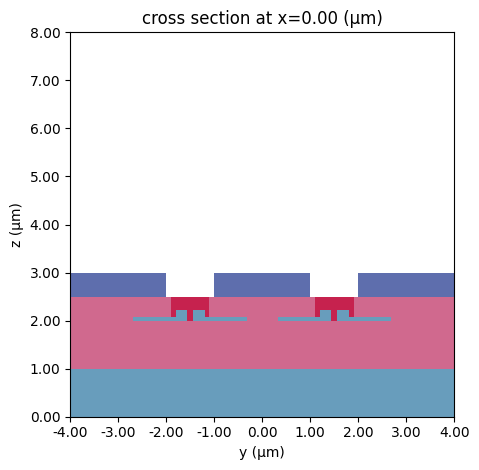

In [9]:
# Create and visualize the RF scene cross-section

scene = td.Scene(structures=structures_RF)
ax = scene.plot(x=0)
ax.set_xlim(-4, 4)
ax.set_ylim(0, 8)
plt.show()

## RF Simulation <a name="2"></a>

Now we will define a [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) object to calculate the RF modes.

First, we define a [LayerRefinementSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.LayerRefinementSpec.html) to refine the mesh around the metal structures and set the global mesh configuration, adding a [MeshOverrideStructure](https://docs.flexcompute.com/projects/tidy3d/en/v2.9.2/api/_autosummary/tidy3d.MeshOverrideStructure.html) to properly resolve the optical waveguide.

In [10]:
# Layer refinement around CPW structures
refinement = 10
lr_spec = td.LayerRefinementSpec.from_structures(
    structures=[cpw],
    min_steps_along_axis=5,
    corner_refinement=td.GridRefinement(dl=cpw_thickness / refinement, num_cells=5),
    refinement_inside_sim_only=False,
)

# Mesh override for the waveguide region (finer mesh in the z-direction)
mins, maxs = slot_waveguide_left.bounds
center_waveguide = 0.5 * (np.array(mins) + np.array(maxs))

override_region = td.MeshOverrideStructure(
    geometry=td.Box(
        size=(eff_inf, slot_width, slot_height),
        center=(0, -center_gap, center_waveguide[2]),
    ),
    dl=(None, 0.02, 0.02),
)

# Global grid specification for the RF simulation
grid_spec_RF = td.GridSpec.auto(
    min_steps_per_sim_size=150,
    wavelength=td.C_0 / max(rf_freqs),
    layer_refinement_specs=[lr_spec],
    override_structures=[override_region],
)

Next, we will define an auxiliary function to correctly place the integral paths for calculating impedance and voltage.

In [11]:
def add_gsg_integrals(ground_left, signal, ground_right, plane="x"):
    """
    Create current and voltage integrals for a GSG (ground-signal-ground) CPW cross-section.

    Parameters
    ----------
    ground_left : tidy3d.Structure or geometry
        Left ground conductor.
    signal : tidy3d.Structure or geometry
        Signal conductor.
    ground_right : tidy3d.Structure or geometry
        Right ground conductor.
    plane : {'x', 'y', 'z'}, optional
        Normal axis of the cross-sectional plane. Default is ``'x'``.

    Returns
    -------
    tuple
        (I_int, V_int) current and voltage integral objects.
    """
    # Extract geometries if structures are provided
    if isinstance(ground_left, td.Structure):
        ground_left_geom = ground_left.geometry
    else:
        ground_left_geom = ground_left

    if isinstance(signal, td.Structure):
        signal_geom = signal.geometry
    else:
        signal_geom = signal

    # Determine in-plane axes
    axis = {"x": 0, "y": 1, "z": 2}[plane]
    aux = [0, 1, 2]
    aux.remove(axis)
    horizontal_axis = min(aux)
    vertical_axis = max(aux)

    gap = signal_geom.bounds[0][horizontal_axis] - ground_left_geom.bounds[1][horizontal_axis]

    height = signal_geom.bounding_box.size[vertical_axis] * 2
    width = signal_geom.bounding_box.size[horizontal_axis] + gap

    # Current integration loop around the signal conductor
    I_int = rf.AxisAlignedCurrentIntegral(
        center=signal_geom.bounding_box.center,
        size=(
            0,
            width,
            height,
        ),
        sign="+",
    )

    center_gap = list(signal_geom.bounding_box.center)
    center_gap[horizontal_axis] = signal_geom.bounds[1][horizontal_axis] + gap / 2
    size = [0, 0, 0]
    size[horizontal_axis] = gap

    # Voltage integration path from signal to ground
    V_int = rf.AxisAlignedVoltageIntegral(
        center=center_gap,
        size=size,
        sign="-",
    )

    return I_int, V_int


I_int, V_int = add_gsg_integrals(ground_left, signal, ground_right)

We can now define our [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) object and visualize the setup.

18:53:41 -03 WARNING: RF simulations and functionality will require new license 
             requirements in an upcoming release. All RF-specific classes are   
             now available within the sub-package 'tidy3d.rf'.                  
              - Contains a 'LossyMetalMedium'.                                  

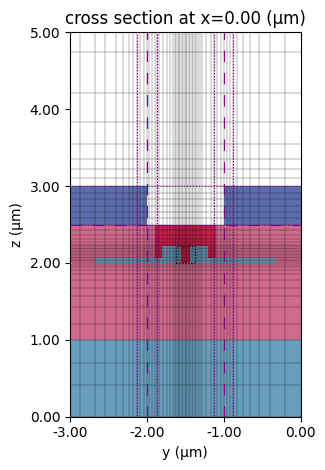

In [12]:
# RF simulation setup
sim_RF = td.Simulation(
    grid_spec=grid_spec_RF,
    structures=structures_RF,
    center=signal.bounding_box.center,
    size=(10, 100, 100),
    run_time=1e-12,
)

# RF mode solver configuration
mode_RF = ModeSolver(
    simulation=sim_RF,
    plane=td.Box(
        center=signal.bounding_box.center,
        size=(0, 100, 100),
    ),
    mode_spec=td.ModeSpec(num_modes=10, target_neff=1.5),
    freqs=[rf_freqs[5]],
)

# Plot modes and grid
ax = mode_RF.plot()
mode_RF.plot_grid(ax=ax)
ax.set_xlim(-3, 0)
ax.set_ylim(0, 5)

plt.show()

We can also visualize the integral paths to ensure they are defined correctly.

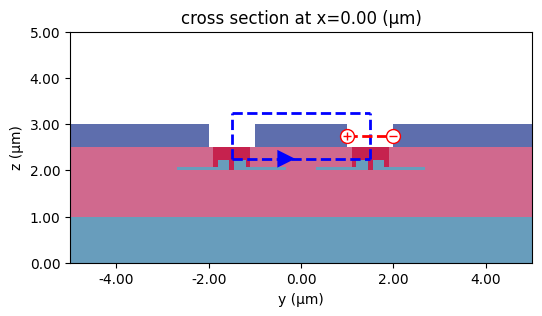

In [13]:
# Plot voltage and current integration paths
fig, ax = plt.subplots(figsize=(10, 3))
mode_RF.plot(ax=ax)
I_int.plot(x=0, ax=ax)
V_int.plot(x=0, ax=ax)
ax.set_xlim(-5, 5)
ax.set_ylim(0, 5)
plt.show()

Finally, we can run the RF mode solver and process the data.

In [14]:
# Run the RF mode solver simulation
data_RF = web.run(mode_RF, task_name="mode_solver_RF")

18:53:43 -03 Created task 'mode_solver_RF' with resource_id                     
             'mo-3c7ac757-adb0-4f3f-a086-fa1be7189e7c' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=613237;https://tidy3d.simulation.cloud/workbench?taskId=mo-3c7ac757-adb0-4f3f-a086-fa1be7189e7c\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=188024;https://tidy3d.simulation.cloud/workbench?taskId=mo-3c7ac757-adb0-4f3f-a086-fa1be7189e7c\taskId]8;;\]8;id=613237;https://tidy3d.simulation.cloud/workbench?taskId=mo-3c7ac757-adb0-4f3f-a086-fa1be7189e7c\=]8;;\]8;id=76822;https://tidy3d.simulation.cloud/workbench?taskId=mo-3c7ac757-adb0-4f3f-a086-fa1be7189e7c\mo]8;;\]8;id=613237;https://tidy3d.simulation.cloud/workbench?taskId=mo-3c7ac757-adb0-4f3f-a086-fa1be7189e7c\-3c7ac757-adb0-]8;;\
             ]8;id=613237;https://tidy3d.simulation.cloud/workbench?taskId=mo-3c7ac757-adb0-4f3f-a086-fa1be7189e7c\4f3f-a086-fa1be7189e7c']8;;\.

             Task folder: ]8;id=72311;https://tidy3d.simulation.cloud/folders/folder-f9e994c1-6315-4b44-af3a-c2cb1435b23a\'default']8;;\.

Output()

18:53:46 -03 Estimated FlexCredit cost: 0.007. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

18:53:49 -03 status = success

Output()

18:54:00 -03 Loading simulation from simulation_data.hdf5

First, we can visualize the RF fields and inspect their overlap with the optical waveguide.

             WARNING: RF simulations and functionality will require new license 
             requirements in an upcoming release. All RF-specific classes are   
             now available within the sub-package 'tidy3d.rf'.                  
              - Contains a 'LossyMetalMedium'.                                  
              - Contains monitors defined for RF wavelengths.                   

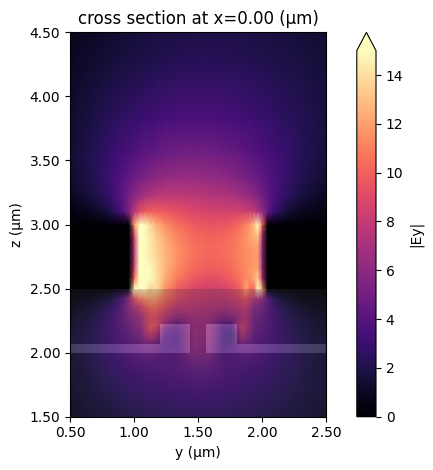

In [15]:
# Plot the magnitude of the Ey field for the first mode
ax = mode_RF.plot_field("Ey", "abs", mode_index=0, robust=False, vmax=15, shading="gouraud")
ax.set_xlim(0.5, 2.5)
ax.set_ylim(1.5, 4.5)

plt.show()

## Optical Simulation <a name="3"></a>

Next, we define an optical simulation and solve for the propagating mode.

In [ ]:
# Simulation domain, sources, and monitors

sim_size = (10, 10, 5)
sim_center = (0, 0, 4)

half_z = 0.5 * sim_size[2]
substrate_thickness = 2.0
substrate_center_z = -half_z + substrate_thickness / 2

substrate_geom = td.Box(
    center=(0, 0, substrate_center_z),
    size=(sim_size[0], sim_size[1], substrate_thickness),
)

substrate = td.Structure(geometry=substrate_geom, medium=oxide, name="substrate")

# Optical grid specification
grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=50,
    override_structures=[],
    wavelength=1.55,
)

mode_spec = td.ModeSpec(num_modes=1, target_neff=organic_index)
source_span_y = max(slot_width, 4 * rail_width)
source_span_z = 3 * slot_height

# Field monitor in a cross-sectional plane
field_monitor = td.FieldMonitor(
    center=(0, 0, 0),
    size=(0, sim_size[1], sim_size[2]),
    freqs=[freq0],
    name="field_slice",
)

simulation_optical = td.Simulation(
    size=sim_size,
    center=sim_center,
    grid_spec=grid_spec,
    structures=structures_optical,
    sources=[],
    monitors=[],
    run_time=1e-12,
)

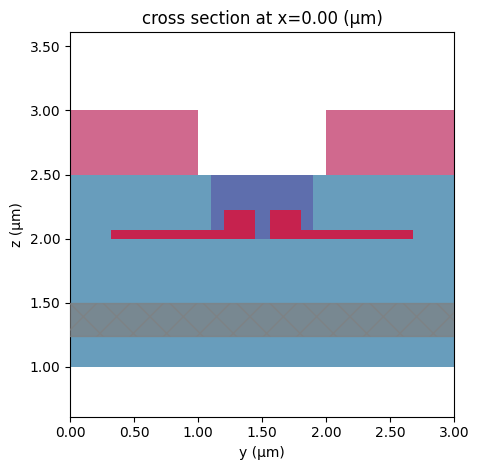

In [17]:
# Optical mode solver setup
mode_solver_center = (0, center_gap, center_waveguide[2])
mode_solver_size = (0, 3, 3)

ms = ModeSolver(
    simulation=simulation_optical,
    plane=td.Box(
        center=mode_solver_center,
        size=mode_solver_size,
    ),
    mode_spec=td.ModeSpec(num_modes=2),
    freqs=[freq0],
)

# Plot the computed modes
ms.plot()
plt.show()

In [18]:
# Run the optical mode solver simulation
mode_data = web.run(ms, task_name="mode_solver")

18:54:01 -03 Created task 'mode_solver' with resource_id                        
             'mo-34b3abf4-9dd0-490b-aec1-d385d5b8a9f8' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=168430;https://tidy3d.simulation.cloud/workbench?taskId=mo-34b3abf4-9dd0-490b-aec1-d385d5b8a9f8\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=216388;https://tidy3d.simulation.cloud/workbench?taskId=mo-34b3abf4-9dd0-490b-aec1-d385d5b8a9f8\taskId]8;;\]8;id=168430;https://tidy3d.simulation.cloud/workbench?taskId=mo-34b3abf4-9dd0-490b-aec1-d385d5b8a9f8\=]8;;\]8;id=966854;https://tidy3d.simulation.cloud/workbench?taskId=mo-34b3abf4-9dd0-490b-aec1-d385d5b8a9f8\mo]8;;\]8;id=168430;https://tidy3d.simulation.cloud/workbench?taskId=mo-34b3abf4-9dd0-490b-aec1-d385d5b8a9f8\-34b3abf4-9dd0-]8;;\
             ]8;id=168430;https://tidy3d.simulation.cloud/workbench?taskId=mo-34b3abf4-9dd0-490b-aec1-d385d5b8a9f8\490b-aec1-d385d5b8a9f8']8;;\.

             Task folder: ]8;id=842890;https://tidy3d.simulation.cloud/folders/folder-f9e994c1-6315-4b44-af3a-c2cb1435b23a\'default']8;;\.

Output()

18:54:04 -03 Estimated FlexCredit cost: 0.013. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

18:54:06 -03 status = success

Output()

18:54:16 -03 Loading simulation from simulation_data.hdf5

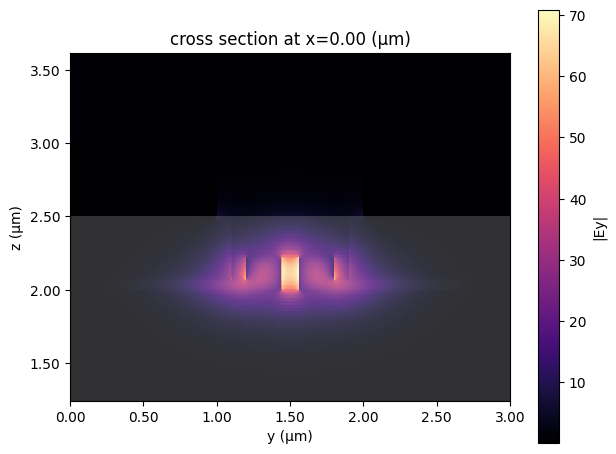

In [19]:
# Plot the magnitude of the Ey field for the first optical mode
ax = ms.plot_field("Ey", "abs", mode_index=0, robust=False)
plt.show()

## Pockels Effect Calculation <a name="4"></a>

Now that we have the optical simulation and the RF fields, we can perturb the optical simulation by considering the Pockels effect.

We first normalize the RF fields by the voltage, use the formula for the Pockels effect

$$-0.5 n_0^3 r_{33} E$$

and create a perturbed medium for the polymer extraordinary axis using a [CustomAnisotropicMedium](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.CustomAnisotropicMedium.html) object.

Finally, we scale it for different voltages.

In [20]:
def perturbed_solver(Voltage, absolute=True):
    """
    Build a perturbed optical simulation and mode solver under an applied voltage.

    The refractive index of the organic region is modified using the
    electro-optic effect based on the RF electric field distribution.

    Parameters
    ----------
    Voltage : float
        Applied voltage used to scale the refractive index perturbation.
    absolute : bool, optional
        If True, use the magnitude of the RF electric field. If False,
        use the real part. Default is True.

    Returns
    -------
    tuple
        (perturbed_sim, perturbed_mode_solver)
    """
    e_field = data_RF.Ey
    V0 = abs(V_int.compute_voltage(data_RF).sel(mode_index=0).isel(f=0, drop=True))
    r33 = 144e-6  # µm/V
    n0 = 1.7

    if absolute:
        e_norm = (e_field / V0.real).isel(mode_index=0, f=0, drop=True).abs
    else:
        e_norm = (e_field / V0.real).isel(mode_index=0, f=0, drop=True).real

    delta_n = -0.5 * n0**3 * r33 * e_norm

    eps_o_array = td.SpatialDataArray(
        np.full((1, 1, 1), n0**2), coords={"x": [0], "y": [0], "z": [0]}
    )
    eps_e_array = (n0 + delta_n * Voltage) ** 2

    perturbed_medium = td.CustomAnisotropicMedium(
        xx=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
        yy=td.CustomMedium(permittivity=eps_e_array, subpixel=True),
        zz=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
    )

    perturbed_organic_fill = organic_fill.updated_copy(medium=perturbed_medium)
    perturbed_sim = simulation_optical.updated_copy(
        structures=[sio2, cpw, perturbed_organic_fill, waveguide]
    )
    perturbed_mode_solver = ModeSolver(
        simulation=perturbed_sim,
        plane=ms.plane,
        mode_spec=td.ModeSpec(num_modes=1),
        freqs=[freq0],
    )
    return perturbed_sim, perturbed_mode_solver

### Calculating $V_\pi$

To calculate $V_\pi$, we create a batch of simulations for different voltages.

In [21]:
# Run perturbed mode solvers for a range of applied voltages
voltages = np.arange(11)
sims = {str(v): perturbed_solver(v)[1] for v in voltages}

perturbed_data = web.run(
    sims,
    task_name="perturbed_mode_solver",
    reduce_simulation=True,
)

Output()

18:54:28 -03 Started working on Batch containing 11 tasks.

18:54:47 -03 Maximum FlexCredit cost: 0.115 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

18:55:16 -03 Batch complete.

In [22]:
# Extract effective index for the fundamental mode at each voltage
n_eff = [sim_data.n_eff.isel(mode_index=0, f=0).item() for sim_data in perturbed_data.values()]

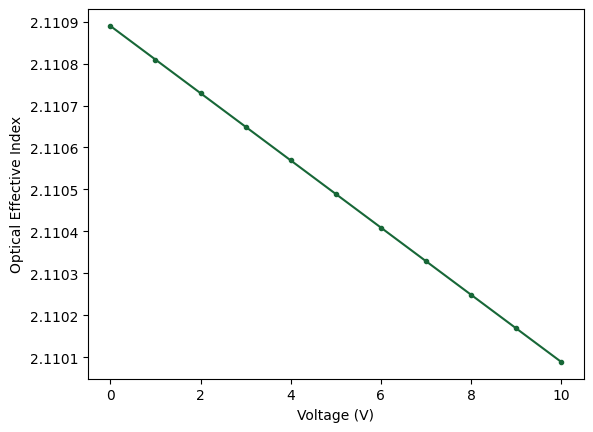

In [23]:
# Plot effective index versus applied voltage
_ = plt.plot(voltages, n_eff, ".-")
_ = plt.ticklabel_format(style="plain", useOffset=False)
plt.gca().set(xlabel="Voltage (V)", ylabel="Optical Effective Index")

plt.show()

In [24]:
# The variation is approximately linear, so use the full voltage range
dneff_dV = abs(n_eff[-1] - n_eff[0]) / (voltages[-1] - voltages[0])

vpil = 0.5 * 1.55 / dneff_dV  # V·µm

print(f"Vπ·L (push-pull) = {vpil * 1e-4 / 2:.2f} V·cm")

Vπ·L (push-pull) = 0.48 V·cm
